In [62]:
import torch 
import torchvision
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm

import pandas as pd 
import numpy as np 
import seaborn as sns 
import os 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import zipfile 
from torchvision import datasets, transforms
from torchsummary import summary 
from torch.utils.data import Dataset
from PIL import Image
import glob
from torchvision.utils import make_grid
from torch.utils.data import Subset
import shutil
from pathlib import Path

### Importing necessary datasets


In [2]:
import kagglehub


path = kagglehub.dataset_download("ajitkumarsenthil/metadata")

print("Path to dataset files:", path)



In [3]:

path = kagglehub.dataset_download("ajitkumarsenthil/dataset1")

print("Path to dataset files:", path)

In [4]:


path = kagglehub.dataset_download("ajitkumarsenthil/dataset2")

print("Path to dataset files:", path)

In [5]:

path = kagglehub.dataset_download("ajitkumarsenthil/dataset3")

print("Path to dataset files:", path)

### Merging the datafolders into a single folder

In [6]:

SOURCE_FOLDERS = [
    '/kaggle/input/dataset1/imgs_part_1/',
    '/kaggle/input/dataset2/imgs_part_2/',
    '/kaggle/input/dataset3/imgs_part_3/'
]

# 2. The single folder where you want all images to end up
DESTINATION_FOLDER = '/kaggle/working/all_images/'



# Create the destination folder if it doesn't exist
os.makedirs(DESTINATION_FOLDER, exist_ok=True)

print(f"Merging images into '{DESTINATION_FOLDER}'...")

total_files_copied = 0

for folder in SOURCE_FOLDERS:
   
    for filename in os.listdir(folder):
        source_path = os.path.join(folder, filename)
        destination_path = os.path.join(DESTINATION_FOLDER, filename)

       
        shutil.copy(source_path, destination_path)
        total_files_copied += 1

print(f"\n✅ All folders merged. Copied a total of {total_files_copied} images.")

Merging images into '/kaggle/working/all_images/'...

✅ All folders merged. Copied a total of 2298 images.


### Assigning label index to the Image data respectively according to the metadata

In [7]:

METADATA_FILE = '/kaggle/input/metadata/metadata.csv'
SOURCE_IMAGE_DIR = '/kaggle/working/all_images/' 
LABELED_IMAGE_DIR = '/kaggle/working/labeled_images2/'



def categorize_images(metadata_path, source_dir, dest_dir):
    """
    Reads a metadata CSV and copies images from a source directory
    to labeled subdirectories in a destination directory.
    """
    try:
        df = pd.read_csv(metadata_path)
    except FileNotFoundError:
        print(f"Error: The file '{metadata_path}' was not found.")
        return

    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
        print(f"Created directory: {dest_dir}")

    labels = df['diagnostic'].unique()
    for label in labels:
        label_path = os.path.join(dest_dir, label)
        if not os.path.exists(label_path):
            os.makedirs(label_path)

    images_copied = 0
    images_not_found = 0

    print("\nStarting image categorization...")
    for index, row in df.iterrows():
        image_id = row['img_id']
        label = row['diagnostic']

        source_image_path = os.path.join(source_dir, image_id)
        dest_image_path = os.path.join(dest_dir, label, image_id)

        if os.path.exists(source_image_path):
            # --- The key change is here: use copy instead of move ---
            shutil.copy(source_image_path, dest_image_path)
            images_copied += 1
        else:
            images_not_found += 1

    print("\n--- Categorization Complete ---")
    print(f" Successfully copied {images_copied} images.")
    print(f" Could not find {images_not_found} images listed in the metadata file.")

In [8]:
categorize_images(METADATA_FILE, SOURCE_IMAGE_DIR, LABELED_IMAGE_DIR)


Starting image categorization...

--- Categorization Complete ---
 Successfully copied 2298 images.
 Could not find 0 images listed in the metadata file.


In [9]:

# Load the dataset
df = pd.read_csv('/kaggle/input/metadata/metadata.csv')

# --- Data Cleaning ---

# For numerical columns, fill missing values with the mean
for col in ['diameter_1', 'diameter_2', 'fitspatrick']:
    df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, fill missing values with the most frequent value (mode)
for col in ['smoke', 'drink', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop columns that are less likely to be useful or have too many unique/missing values
df.drop(columns=['background_father', 'background_mother', 'pesticide'], inplace=True)


print("✅ Data has been cleaned. Missing values handled.")
print("\n--- First 5 Rows of Cleaned Data ---")
print(df.head())

✅ Data has been cleaned. Missing values handled.

--- First 5 Rows of Cleaned Data ---
  patient_id  lesion_id  smoke  drink  age  gender  skin_cancer_history  \
0   PAT_1516       1765  False  False    8  FEMALE                False   
1     PAT_46        881  False  False   55  FEMALE                 True   
2   PAT_1545       1867  False  False   77  FEMALE                False   
3   PAT_1989       4061  False  False   75  FEMALE                False   
4    PAT_684       1302  False   True   79    MALE                 True   

   cancer_history  has_piped_water  has_sewage_system  ...  diameter_2  \
0            True             True               True  ...    8.852209   
1            True             True               True  ...    5.000000   
2            True             True               True  ...    8.852209   
3            True             True               True  ...    8.852209   
4           False            False              False  ...    5.000000   

  diagnostic   it

/tmp/ipykernel_104/644525960.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_104/644525960.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [10]:
# --- Descriptive Statistics ---

print("\n--- Main Dataset Statistics ---")
print(df.describe(include='all'))


--- Main Dataset Statistics ---
       patient_id    lesion_id  smoke  drink          age  gender  \
count        2298  2298.000000   2298   2298  2298.000000    2298   
unique       1373          NaN      2      2          NaN       2   
top       PAT_330          NaN  False  False          NaN  FEMALE   
freq           10          NaN   2096   1930          NaN    1557   
mean          NaN  1529.933856    NaN    NaN    60.464752     NaN   
std           NaN  1196.285644    NaN    NaN    15.894866     NaN   
min           NaN     6.000000    NaN    NaN     6.000000     NaN   
25%           NaN   720.500000    NaN    NaN    52.000000     NaN   
50%           NaN  1297.000000    NaN    NaN    62.000000     NaN   
75%           NaN  1782.750000    NaN    NaN    72.000000     NaN   
max           NaN  4820.000000    NaN    NaN    94.000000     NaN   

       skin_cancer_history cancer_history has_piped_water has_sewage_system  \
count                 2298           2298            2298  

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [11]:
print(df.isnull().sum())

patient_id             0
lesion_id              0
smoke                  0
drink                  0
age                    0
gender                 0
skin_cancer_history    0
cancer_history         0
has_piped_water        0
has_sewage_system      0
fitspatrick            0
region                 0
diameter_1             0
diameter_2             0
diagnostic             0
itch                   0
grew                   0
hurt                   0
changed                0
bleed                  0
elevation              0
img_id                 0
biopsed                0
dtype: int64


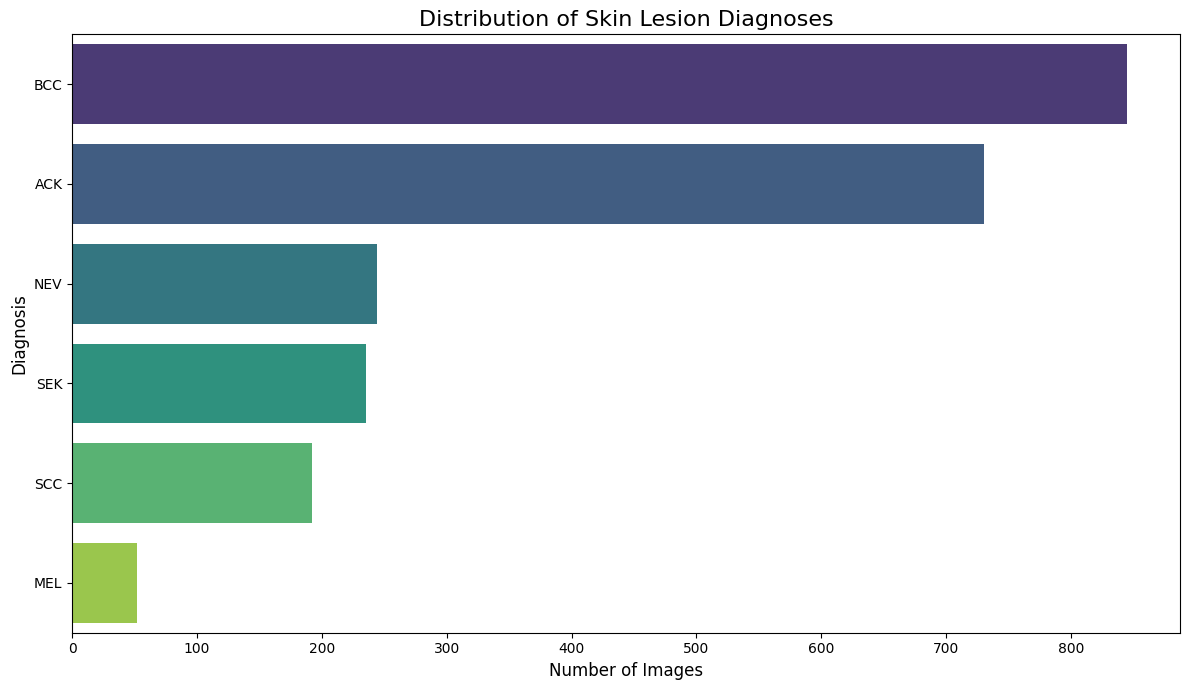

In [12]:
plt.figure(figsize=(12, 7))
sns.countplot(y=df['diagnostic'], order = df['diagnostic'].value_counts().index, palette="viridis")
plt.title('Distribution of Skin Lesion Diagnoses', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


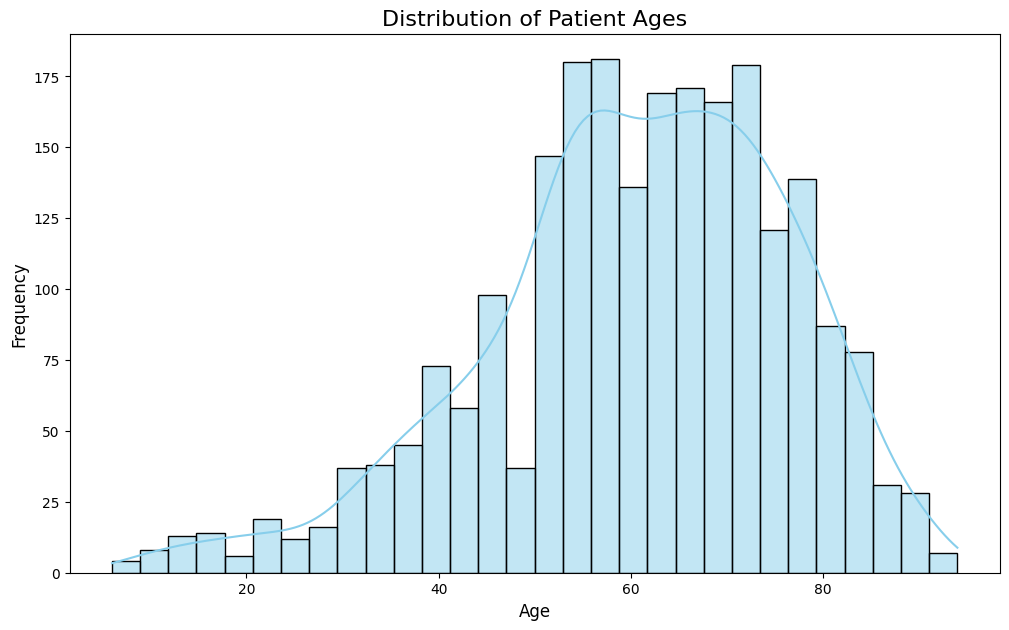

In [13]:
plt.figure(figsize=(12, 7))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Patient Ages', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

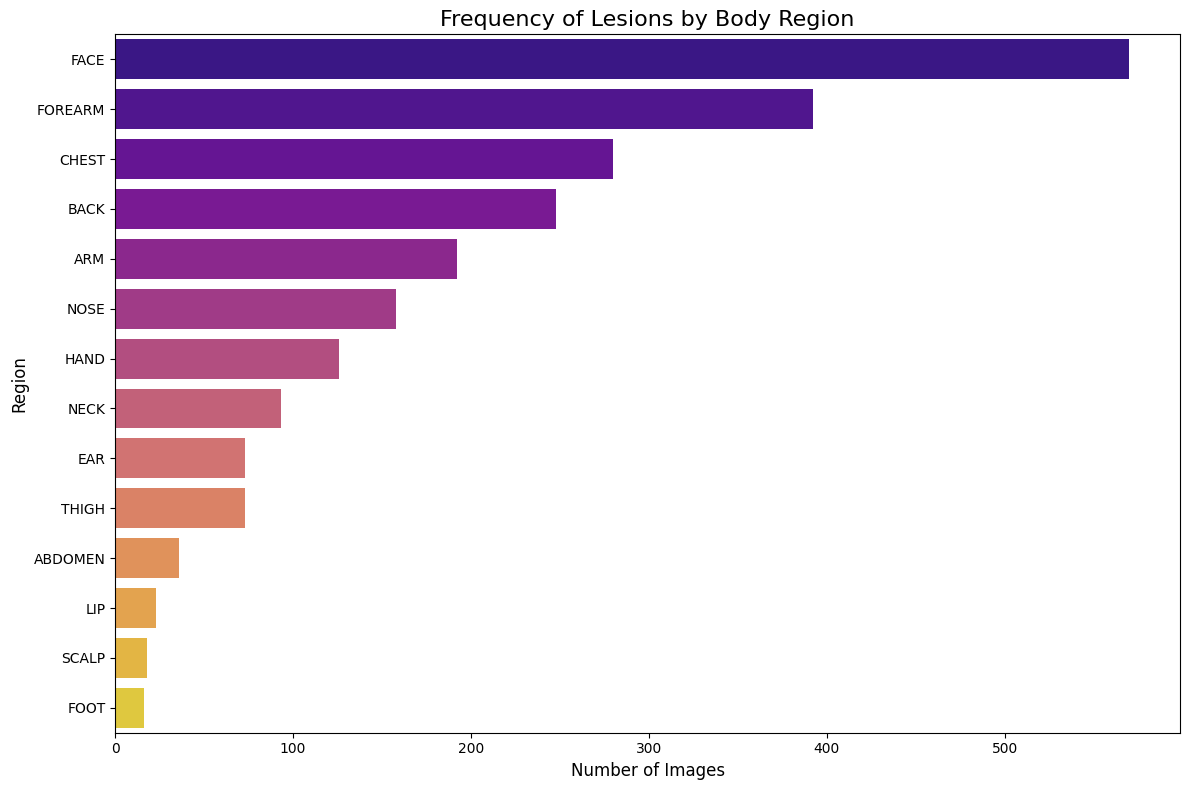

In [14]:
plt.figure(figsize=(12, 8))
sns.countplot(y=df['region'], order=df['region'].value_counts().index, palette="plasma")
plt.title('Frequency of Lesions by Body Region', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

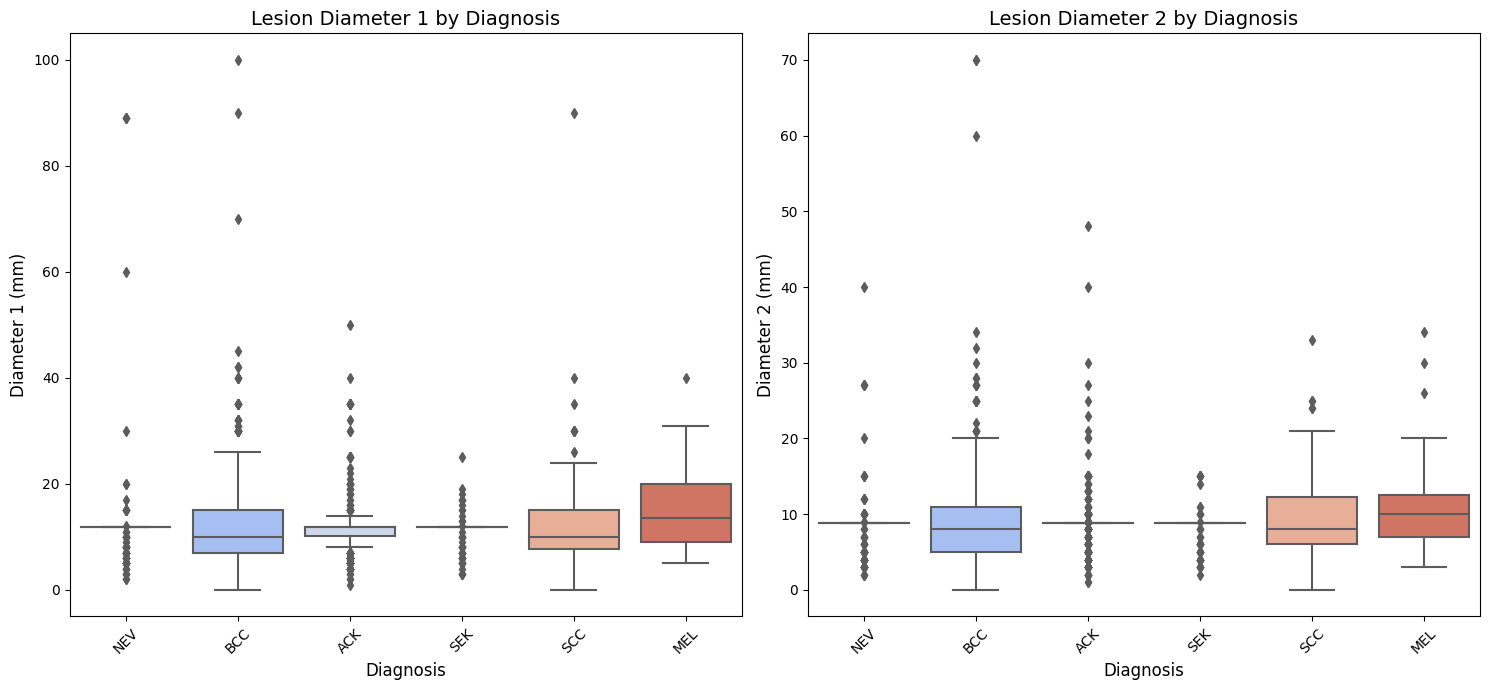

In [15]:
# Plotting both diameters
plt.figure(figsize=(15, 7))

# Diameter 1
plt.subplot(1, 2, 1)
sns.boxplot(x='diagnostic', y='diameter_1', data=df, palette="coolwarm")
plt.title('Lesion Diameter 1 by Diagnosis', fontsize=14)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Diameter 1 (mm)', fontsize=12)
plt.xticks(rotation=45)

# Diameter 2
plt.subplot(1, 2, 2)
sns.boxplot(x='diagnostic', y='diameter_2', data=df, palette="coolwarm")
plt.title('Lesion Diameter 2 by Diagnosis', fontsize=14)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Diameter 2 (mm)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [64]:
def plot_image_grid(data_loader, class_names, num_images=20):
 
    images, labels = next(iter(data_loader))

  
    num_images = min(num_images, len(images))
    rows = int(np.ceil(num_images / 5))
    cols = 5


    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() 

    for i in range(num_images):

        img = images[i]
       
        npimg = img.numpy()

        ax = axes[i]
        ax.imshow(np.transpose(npimg, (1, 2, 0)))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')


    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

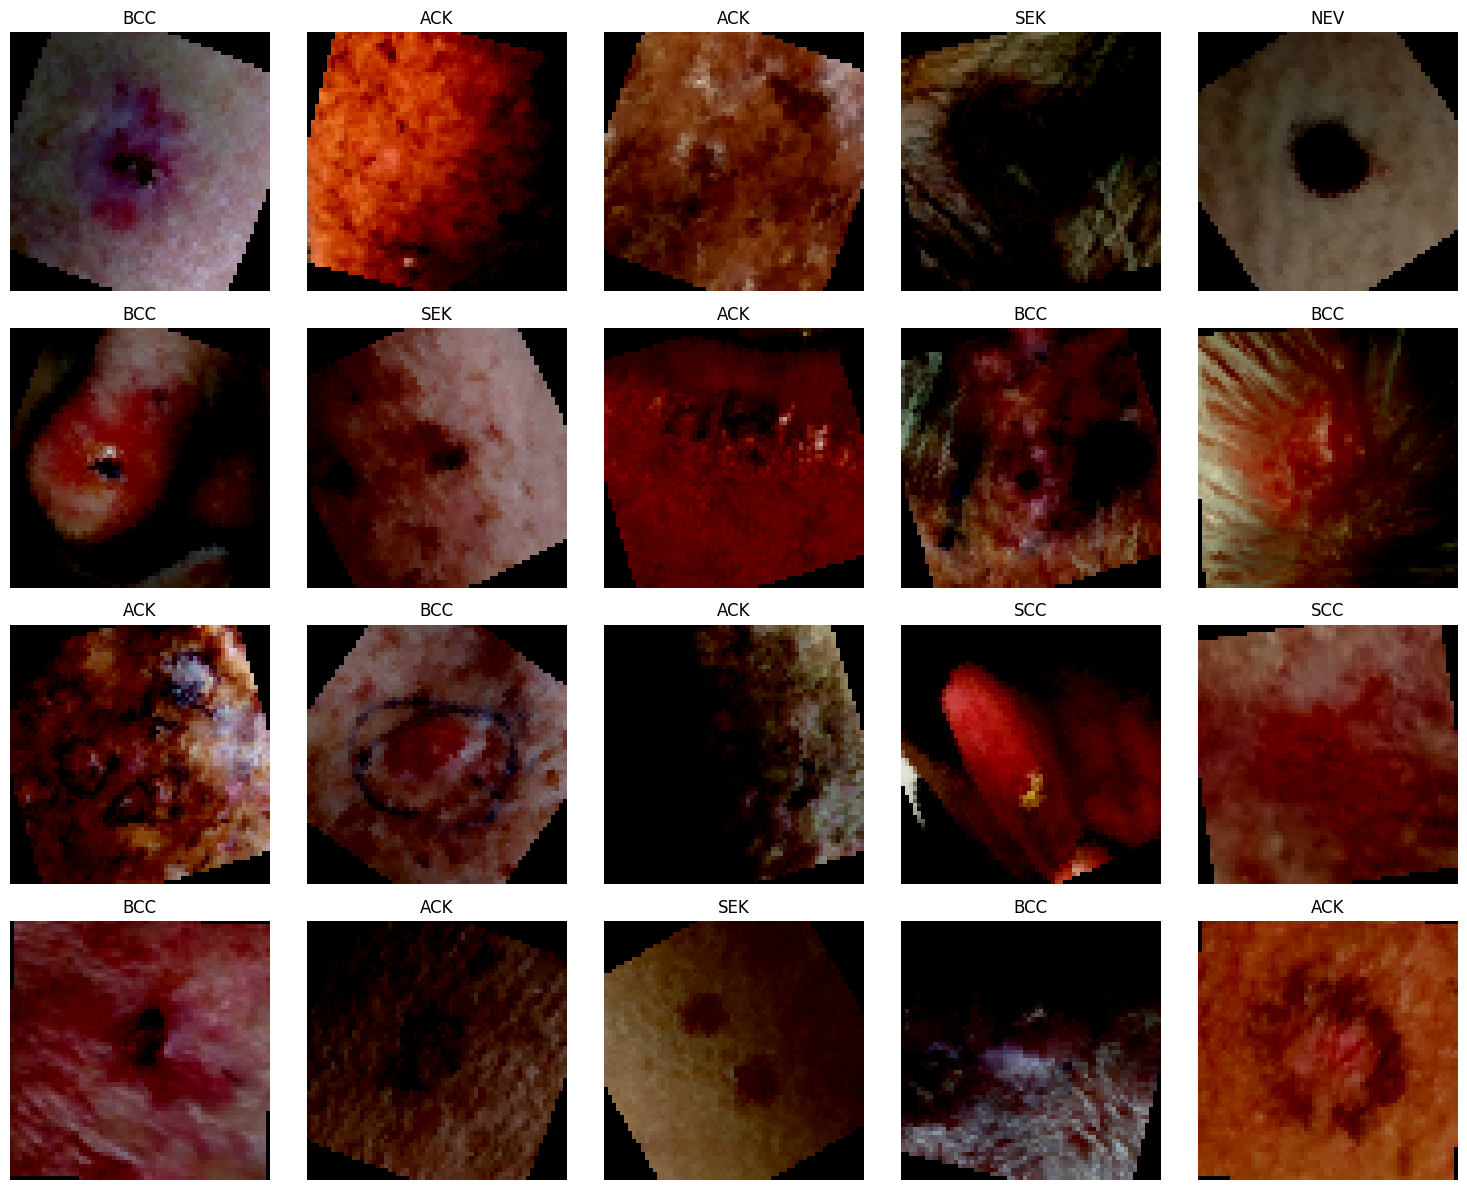

In [65]:
plot_image_grid(train_loader, class_names, num_images=20)

### Defining the train , validation and test dataset split 

In [16]:


train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])])

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.5]*3 , std = [0.5]*3)
])

In [18]:
dataset = datasets.ImageFolder(root="/kaggle/working/labeled_images2/", transform=transform)

class_names = dataset.classes

In [19]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size 

# 3. Split the dataset
# Use a fixed generator for reproducibility
train_subset, val_subset, test_subset = random_split(
    dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)


train_subset.dataset.transform = train_transform

In [20]:
print("Setting up data loaders...")

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False 
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("\n All Done!")
print(f"Total images: {len(dataset)}")
print(f"Training images: {len(train_subset)}")
print(f"Validation images: {len(val_subset)}")
print(f"Test images: {len(test_subset)}")
print(f"\nThere are {len(class_names)} classes: {class_names}")

Setting up data loaders...

 All Done!
Total images: 2298
Training images: 1838
Validation images: 229
Test images: 231

There are 6 classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [21]:
if torch.cuda.device_count() > 1:
  print(f"Using {torch.cuda.device_count()} GPUs!")
 

# Move the model to the device (it will be distributed automatically)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


Using 2 GPUs!


### Lets define our baseline model 


In [22]:
class Cancerdetector(nn.Module):
    def __init__(self, num_classes):
        super(Cancerdetector,self).__init__()
    
        assert num_classes is not None 
        assert num_classes > 1
    
        self.num_classes = num_classes
    
        self.block1 = nn.Sequential(
                nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
       
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    
       
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    
   
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 8 * 8, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=self.num_classes)
        )

    def forward(self, x):
       
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        
        return x

In [31]:
model = nn.DataParallel(Cancerdetector(num_classes = 6))
model.to(device)

DataParallel(
  (module): Cancerdetector(
    (block1): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (classifier): Sequential(
      (0): Flatte

In [32]:
summary(model, input_size =(3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
            Conv2d-2           [-1, 16, 64, 64]             448
       BatchNorm2d-3           [-1, 16, 64, 64]              32
       BatchNorm2d-4           [-1, 16, 64, 64]              32
              ReLU-5           [-1, 16, 64, 64]               0
              ReLU-6           [-1, 16, 64, 64]               0
         MaxPool2d-7           [-1, 16, 32, 32]               0
         MaxPool2d-8           [-1, 16, 32, 32]               0
            Conv2d-9           [-1, 32, 32, 32]           4,640
           Conv2d-10           [-1, 32, 32, 32]           4,640
      BatchNorm2d-11           [-1, 32, 32, 32]              64
             ReLU-12           [-1, 32, 32, 32]               0
      BatchNorm2d-13           [-1, 32, 32, 32]              64
        MaxPool2d-14           [-1, 32,

In [39]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = 0.0002)
scheduler = ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=5,verbose=True)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [53]:
def training_phase(model, train_loader, optimizer, loss_function, device):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images =  images.to(device)
        labels = labels.to(device)

       
        outputs = model(images)
        loss = loss_function(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return train_loss, accuracy




    
    

In [54]:
def validation_phase(model, validation_loader, loss_function, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels =  labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(validation_loader)
    accuracy = correct / total
    
    return val_loss, accuracy


In [60]:
def testing_phase(model, test_loader, device, loss_function):
    
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = loss_function(outputs, labels)
            total_loss += loss.item() * labels.size(0)  

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / total
    accuracy = correct / total

    
    return test_loss, accuracy, all_preds, all_labels


In [55]:

from torch import manual_seed
import time


torch.manual_seed(42)
np.random.seed(42)


best_Acc = 0 
best_epoch = -1
best_val_acc = 0  


epochs = 50 
best_val = np.inf or float('inf')
History_ = [] 
batch_size = 64

train_Data_loader = DataLoader(train_subset, batch_size = batch_size, shuffle = True)
val_Data_loader = DataLoader(val_subset, batch_size = batch_size, shuffle = False)
test_Data_loader = DataLoader(test_subset, batch_size = batch_size, shuffle = False)

start_time = time.time() 

for epoch in range(epochs):
    train_loss_, train_accuracy_ = training_phase(model, train_Data_loader, optimizer, loss_function ,device=device )
    val_loss_, val_accuracy_ = validation_phase(model, val_Data_loader, loss_function , device = device)
    History_.append((train_loss_, train_accuracy_, val_loss_, val_accuracy_))
    
    scheduler.step(val_loss_)

    if val_loss_  < best_val:
        best_val = val_loss_
        torch.save(model.state_dict(), 'baseline_Cnn_model.pth')
    
    if train_accuracy_ > best_Acc:
        best_Acc = train_accuracy_
        best_epoch = epoch + 1
    
    if val_accuracy_ > best_val_acc:
        best_val_acc = val_accuracy_
        best_epoch_val = epoch + 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_:.4f}, Train Accuracy: {train_accuracy_:.4f}, Val Loss: {val_loss_:.4f}, Val Accuracy: {val_accuracy_:.4f}")

end_time = time.time()
duration = end_time - start_time
print(f"Total training time: {duration:.2f} seconds")  
print(f"Best training accuracy of {best_Acc:.4f} was achieved in epoch {best_epoch} || Best validation accuracy of {best_val_acc:.4f} was achieved in epoch {best_epoch_val}")







  

  











Epoch 1/50, Train Loss: 1.5535, Train Accuracy: 0.3770, Val Loss: 1.4857, Val Accuracy: 0.4061
Epoch 3/50, Train Loss: 1.2619, Train Accuracy: 0.5147, Val Loss: 1.1680, Val Accuracy: 0.5983
Epoch 5/50, Train Loss: 1.1577, Train Accuracy: 0.5822, Val Loss: 1.1003, Val Accuracy: 0.6157
Epoch 7/50, Train Loss: 1.1138, Train Accuracy: 0.5800, Val Loss: 1.0630, Val Accuracy: 0.6288
Epoch 9/50, Train Loss: 1.0864, Train Accuracy: 0.5930, Val Loss: 1.0443, Val Accuracy: 0.6026
Epoch 11/50, Train Loss: 1.0749, Train Accuracy: 0.6175, Val Loss: 1.0182, Val Accuracy: 0.6114
Epoch 13/50, Train Loss: 1.0485, Train Accuracy: 0.6072, Val Loss: 1.0031, Val Accuracy: 0.6201
Epoch 15/50, Train Loss: 1.0088, Train Accuracy: 0.6306, Val Loss: 1.0113, Val Accuracy: 0.6419
Epoch 17/50, Train Loss: 1.0282, Train Accuracy: 0.6186, Val Loss: 0.9970, Val Accuracy: 0.6376
Epoch 19/50, Train Loss: 1.0221, Train Accuracy: 0.6088, Val Loss: 0.9860, Val Accuracy: 0.6157
Epoch 21/50, Train Loss: 0.9908, Train Accura

In [61]:
test_loss, test_accuracy, y_pred, y_true = testing_phase(model, test_loader, device,loss_function)

test_history = []
test_history.append((test_loss,test_accuracy))

print(f" Test loss : {test_loss} || Test accuracy : {test_accuracy}" )

 Test loss : 0.9353847467538082 || Test accuracy : 0.658008658008658


In [ ]:

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        # Channel Attention
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        # Spatial Attention
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_attn(x)
        x = x * ca

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.spatial_attn(torch.cat([avg_out, max_out], dim=1))
        x = x * sa

        return x

# --- Hybrid Model with CBAM ---
class CancerHybridNet_CBAM(nn.Module):
    def __init__(self, num_classes: int, num_metadata_features: int = 0, pretrained=True):
        super().__init__()
        self.use_metadata = num_metadata_features > 0

        # --- EfficientNet Pretrained Backbone ---
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=0)
        num_backbone_features = self.backbone.num_features  # 1280 for b0

        # --- Custom CNN Branch ---
        self.custom_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # [B, 64, 1, 1]
        )
        
        self.cbam = CBAM(64)
        self.custom_feature_dim = 64

       
        if self.use_metadata:
            self.metadata_encoder = nn.Sequential(
                nn.Linear(num_metadata_features, 128),
                nn.ReLU(),
                nn.Dropout(0.3)
            )
            metadata_dim = 128
        else:
            metadata_dim = 0

       
        total_features = num_backbone_features + self.custom_feature_dim + metadata_dim
        self.classifier = nn.Sequential(
            nn.Linear(total_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_img, x_meta=None):
        
        x1 = self.backbone(x_img)  

      
        x2 = self.custom_cnn(x_img)  
        x2 = self.cbam(x2)           
        x2 = x2.view(x2.size(0), -1) 

      
        if self.use_metadata and x_meta is not None:
            x3 = self.metadata_encoder(x_meta)  
            x = torch.cat([x1, x2, x3], dim=1)  
        else:
            x = torch.cat([x1, x2], dim=1)

        return self.classifier(x)
